# New Exploratory Analysis (EDA)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import missingno as msno

Accidentes de Tránsito Terrestre en Zonas Urbanas y Suburbanas (ATUS)

La recolección de datos para la elaboración de la estadística de accidentes de tránsito terrestre en zonas urbanas y suburbanas inició en el año 1928, y los procedimientos para su obtención se han modificado paulatinamente.

Esta estadística mide la siniestralidad del transporte a nivel nacional, y se genera a partir del acopio y procesamiento de los datos alusivos a los accidentes ocurren en zonas no federales. Esta información contribuyó a la planeación, organización del transporte y la prevención de accidentes.

## Carga del Dataset

In [6]:
data = '../data/raw/inegi/conjunto_de_datos/atus_anual_2024.csv'

In [ ]:
df = pd.read_csv(data)

# Se elimina la columna 'COBERTURA' ya que tiene un valor constante "MUNICIPAL"
df.drop(columns='COBERTURA', inplace=True)
df.reset_index(drop=True)
df.head(3)

,ID_ENTIDAD,ID_MUNICIPIO,ANIO,MES,ID_HORA,ID_MINUTO,ID_DIA,DIASEMANA,URBANA,SUBURBANA,...,PEATMUERTO,PEATHERIDO,CICLMUERTO,CICLHERIDO,OTROMUERTO,OTROHERIDO,NEMUERTO,NEHERIDO,CLASACC,ESTATUS
0,1,1,2024,1,2,25,1,lunes,Accidente en intersección,Sin accidente en esta zona,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Corregidas
1,1,1,2024,1,3,40,1,lunes,Accidente en intersección,Sin accidente en esta zona,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Corregidas
2,1,1,2024,1,4,37,1,lunes,Accidente en intersección,Sin accidente en esta zona,...,0,1,0,0,0,0,0,0,No fatal,Cifras Corregidas


# Análisis Exploratorio de Datos

Análisis Exploratorio para determinar las visualizaciones en perspectiva de los rangos de edad.

El código 26 en `ID_ENTIDAD` se refiere a Sonora, mientras que el código 30 en `ID_MUNICIPIO` hace referencia a Hermosillo.

In [10]:
# Se crea df_copy para cualquier otro análisis dejando df intacto
df_copy = df.copy()
print(df_copy.shape)

(390627, 44)


In [11]:
# Filtrado del DataFrame para Hermosillo, Sonora (2024)
df_hmo = df_copy[(df_copy['ID_ENTIDAD'] == 26) & (df_copy['ID_MUNICIPIO'] == 30)].copy()
del_obs = df_copy.shape[0] - df_hmo.shape[0]
print(f"Registros eliminados: {del_obs:,.0f}")

Registros eliminados: 378,636


In [12]:
# Se eliminan las columnas con constantes delimitadas para los registros de Hermosillo, Sonora en 2024
df_hmo.drop(columns=['ID_ENTIDAD', 'ID_MUNICIPIO', 'ANIO'], inplace=True)
df_hmo.head(3)

,MES,ID_HORA,ID_MINUTO,ID_DIA,DIASEMANA,URBANA,SUBURBANA,TIPACCID,AUTOMOVIL,CAMPASAJ,...,PEATMUERTO,PEATHERIDO,CICLMUERTO,CICLHERIDO,OTROMUERTO,OTROHERIDO,NEMUERTO,NEHERIDO,CLASACC,ESTATUS
330299,1,2,0,1,lunes,Accidente en intersección,Sin accidente en esta zona,Colisión con vehículo automotor,1,1,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Corregidas
330300,1,2,0,1,lunes,Accidente en intersección,Sin accidente en esta zona,Colisión con objeto fijo,1,0,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Corregidas
330301,1,6,15,1,lunes,Accidente en intersección,Sin accidente en esta zona,Colisión con objeto fijo,1,0,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Corregidas


In [13]:
df_hmo.shape

(11991, 41)

## Matriz de correlación

<Axes: >

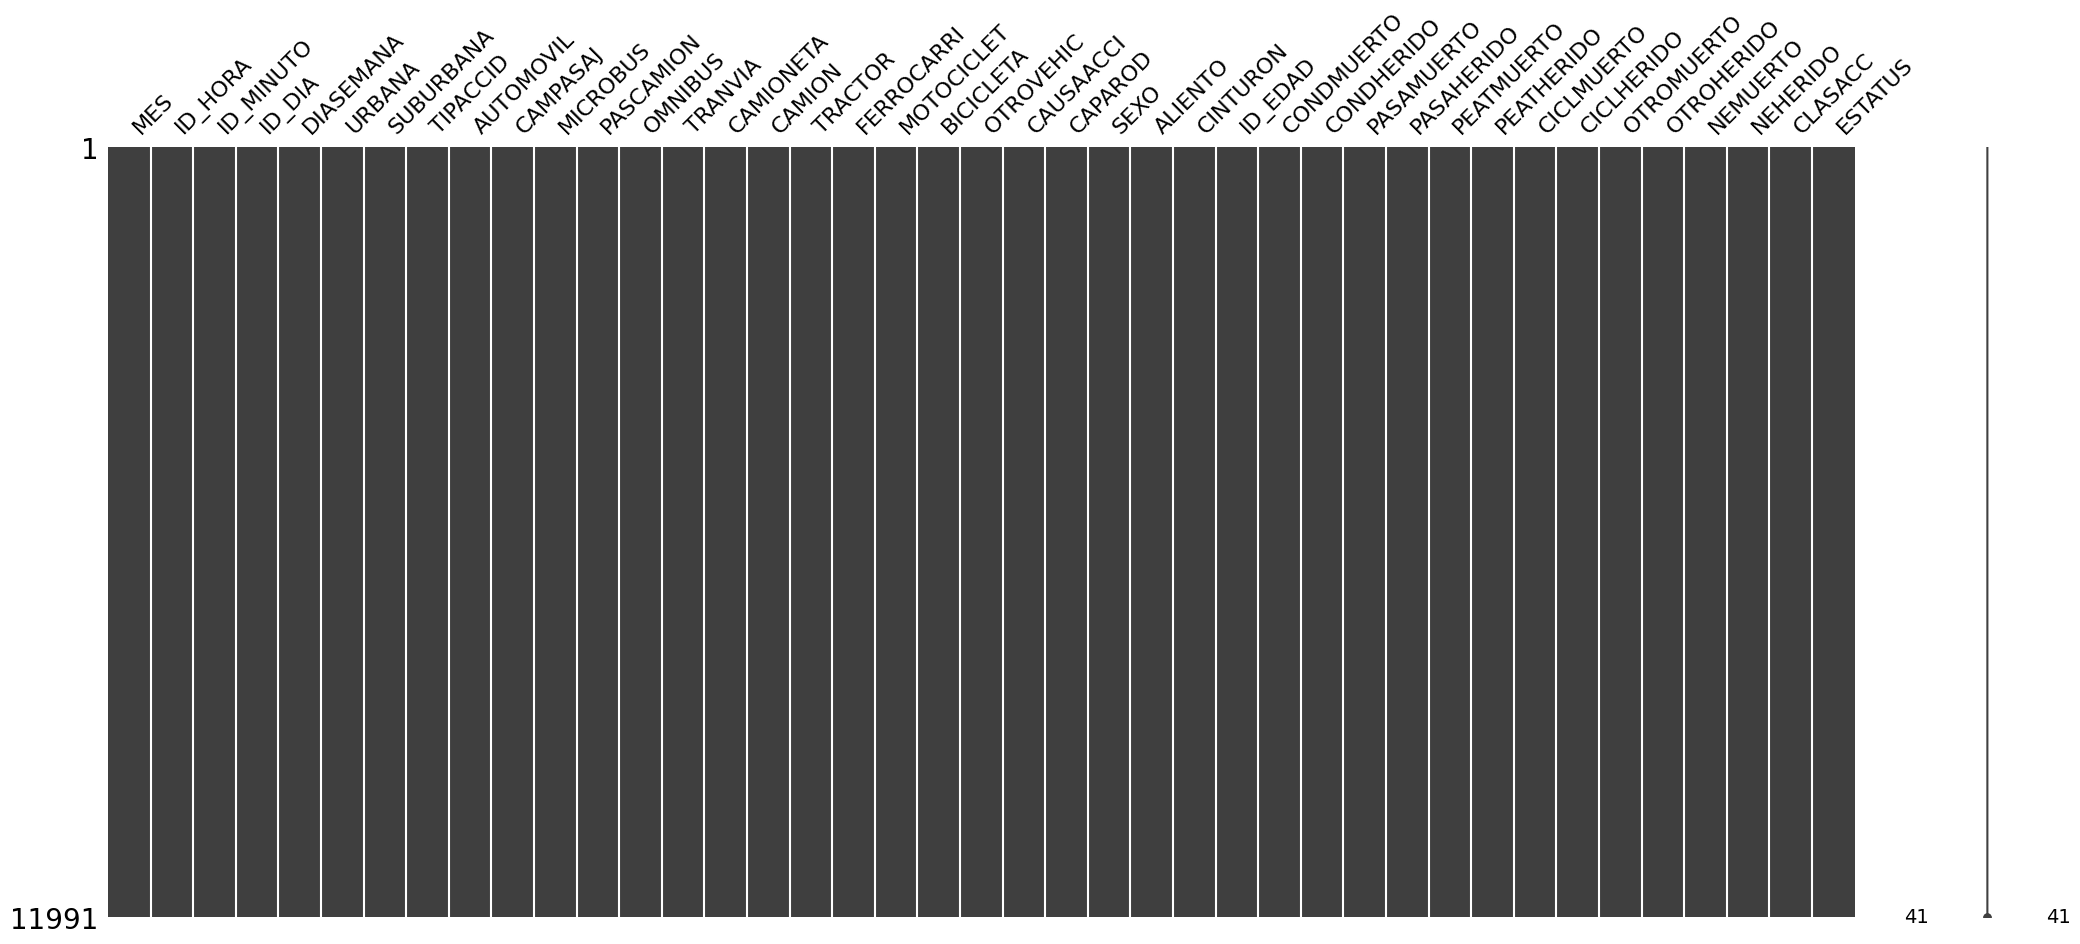

In [14]:
msno.matrix(df_hmo)

In [15]:
df_corr_var = df_hmo.select_dtypes(include='int64')

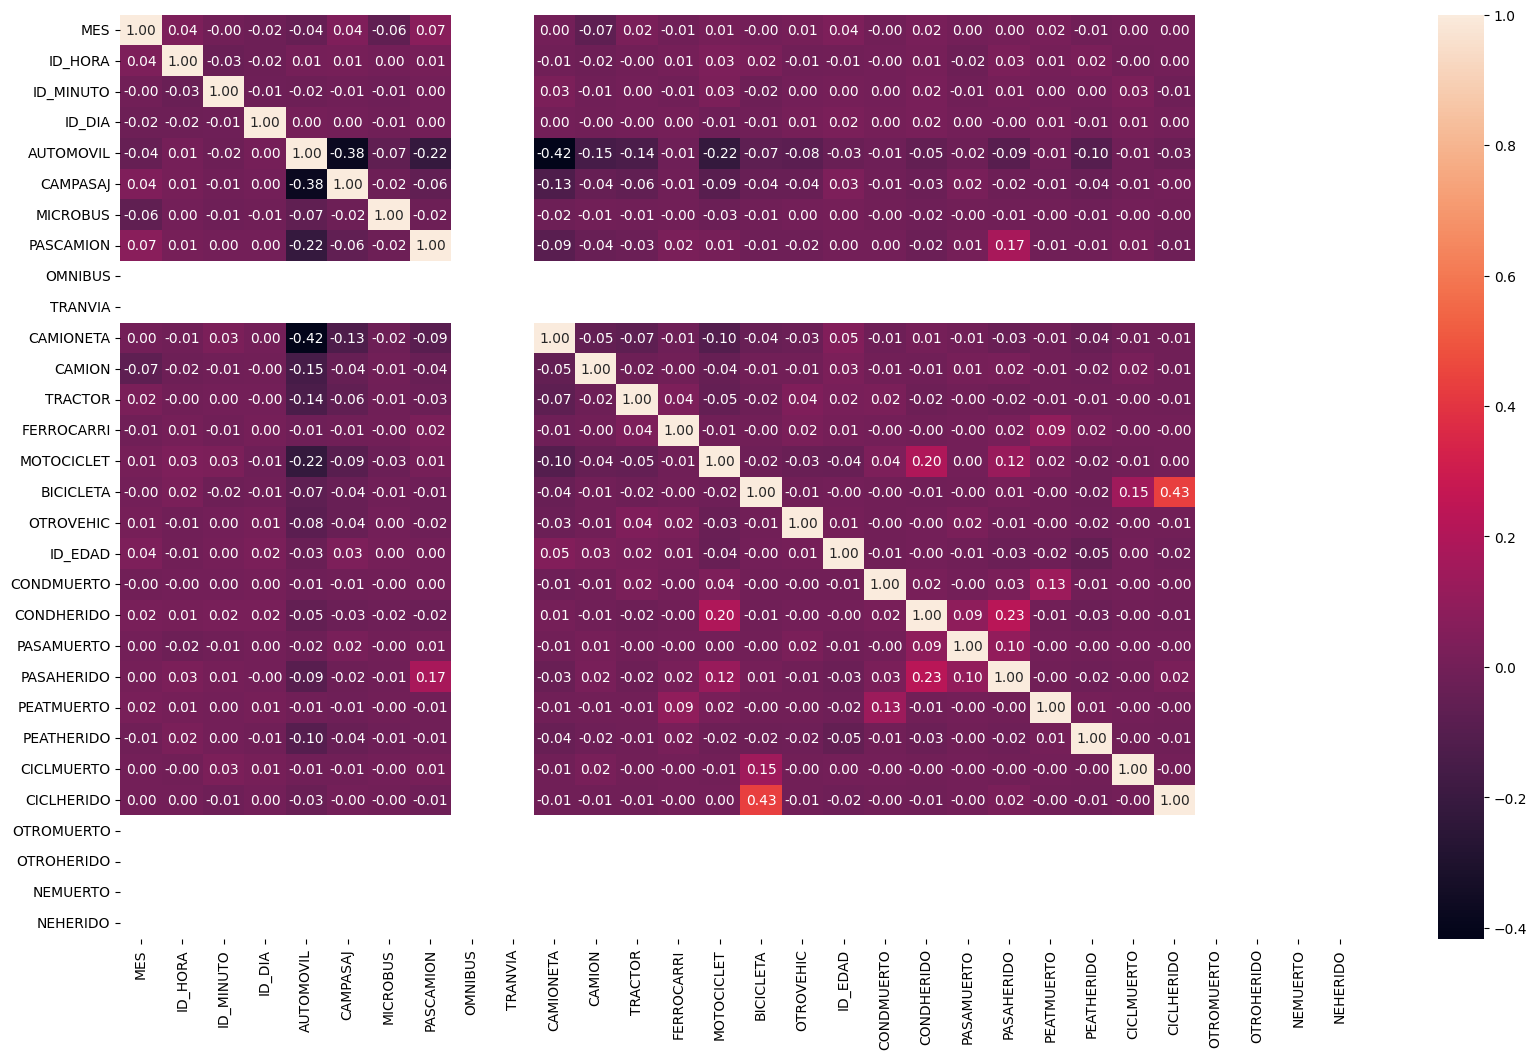

In [16]:
plt.figure(figsize=(20, 12))
sns.heatmap(df_corr_var.corr(), annot=True, fmt=".2f")
plt.show()

Se puede observar una correlación alta entre `BICLICETA` y `CICLHERIDO`, así como `CICMUERTO`. La relación puede ser medida para obtener el índice de fatalidad entre un conductor de automóvil y un ciclista involucrados en un accidente de tránsito.

## Efecto del Último Viernes

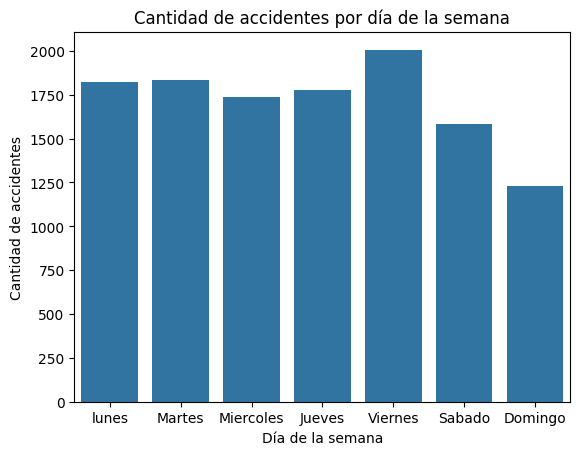

In [17]:
sns.countplot(data=df_hmo, x='DIASEMANA')
plt.xlabel('Día de la semana')
plt.ylabel('Cantidad de accidentes')
plt.title('Cantidad de accidentes por día de la semana')
plt.show()

In [18]:
# Proporción de accidentes por día de la semana
df_hmo['DIASEMANA'].value_counts(normalize=True)

DIASEMANA
Viernes      0.167376
Martes       0.153031
lunes        0.151947
Jueves       0.148278
Miercoles    0.144692
Sabado       0.132266
Domingo      0.102410
Name: proportion, dtype: float64

$H_0$: No hay diferencia entre los días. Los incidentes se distribuyen uniformemente a lo largo de la semana.

La probabilidad de accidentes cada día es equivalente $p_0=0.1429$. Se toma un $\alpha = 0.05$.

La prueba será Chi-cuadrado ($x^{2}$) de bondad de ajuste.

$$x^{2}=\sum \frac{(O-E)^{2}} {E}$$

Donde $O$ es la frecuencia obtenida y $E$ es la frecuencia esperada.

In [19]:
df_stats = df_hmo.value_counts('DIASEMANA')
df_week_stats = df_stats.to_frame()

df_week_stats['pcc'] = df_week_stats['count'] / df_week_stats['count'].sum()

# Variables para Chi-cuadrado
pcc_esperada = 1 / 7 # Valor de E
n = df_hmo.shape[0]

# Sumar la chi cuadrada con las diferencias al cuadrado
df_week_stats['x_2'] = ( (df_week_stats['count'] - (n * pcc_esperada)) ** 2) / (n * pcc_esperada)
chi_cuadrada = df_week_stats['x_2'].sum()

print(f"Chi-cuadrada: {chi_cuadrada:.2f}\n")
display(df_week_stats)

Chi-cuadrada: 215.57



,count,pcc,x_2
DIASEMANA,,,
Viernes,2007,0.167376,50.458844
Martes,1835,0.153031,8.688850
lunes,1822,0.151947,6.935785
Jueves,1778,0.148278,2.466433
Miercoles,1735,0.144692,0.282545
Sabado,1586,0.132266,9.415645
Domingo,1228,0.102410,137.317572


In [20]:
from scipy import stats

grados_libertad = 7 - 1 # Valor de K
p_value = stats.chi2.sf(x=chi_cuadrada, df=grados_libertad)

print(f"p-value: {p_value:.4f}")

p-value: 0.0000


Con un p-valor = $0$, se rechaza la Hipotesis nula debido a la diferencia que existen entre Domingo y Viernes, con certeza no se encuentran uniformemente distribuidos.

Conociendo que el día viernes existen más accidentes de tránsito, se hará una observación a este día por cada mes para determinar factores relevantes, entre ellos el hecho de que existe consejo técnico escolar y no hay asistencia de alumnos a las escuelas.

In [21]:
# El último viernes de cada mes hay consejo técnico
df_semana = df_hmo.groupby(['MES', 'ID_DIA', 'DIASEMANA']).size().reset_index(name='count')
df_semana = df_semana.sort_values(by=['MES', 'ID_DIA'])
df_los_viernes = df_semana[df_semana['DIASEMANA'] == 'Viernes'].copy()
display(df_los_viernes.head(3))

,MES,ID_DIA,DIASEMANA,count
4,1,5,Viernes,31
11,1,12,Viernes,47
18,1,19,Viernes,45


In [22]:
# Agrupamos por mes y asignamos un número secuencial
df_los_viernes['num_viernes'] = df_los_viernes.groupby('MES').cumcount() + 1
display(df_los_viernes.head(5))

,MES,ID_DIA,DIASEMANA,count,num_viernes
4,1,5,Viernes,31,1
11,1,12,Viernes,47,2
18,1,19,Viernes,45,3
25,1,26,Viernes,32,4
32,2,2,Viernes,30,1


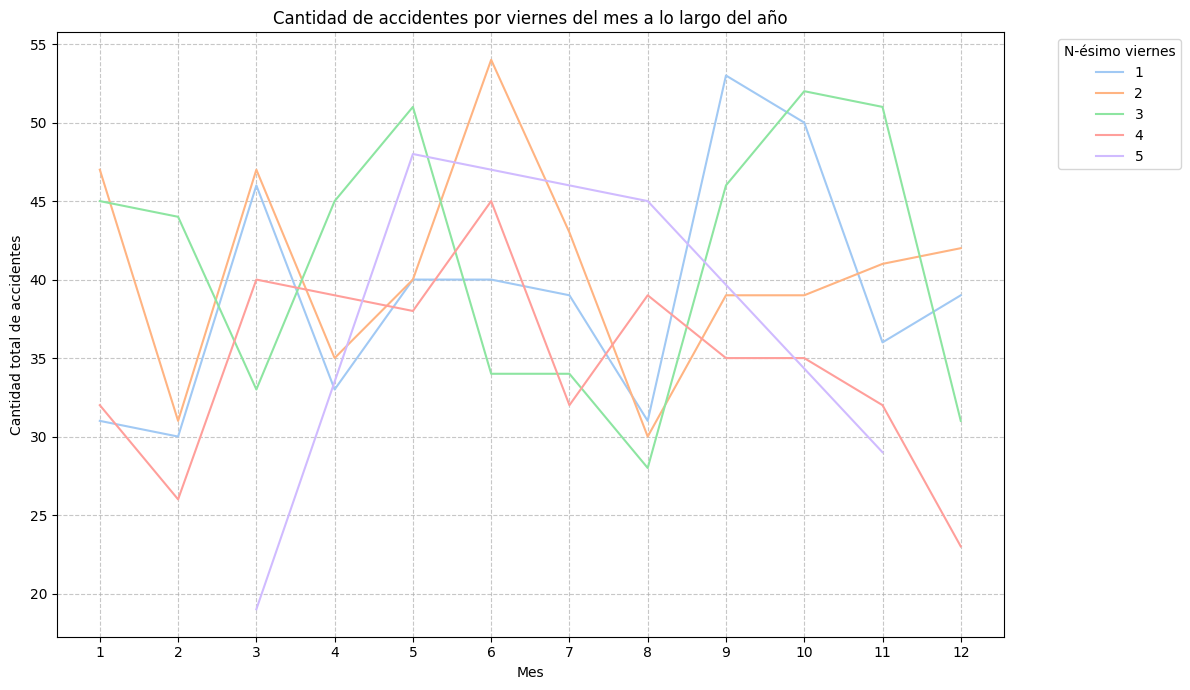

In [23]:
plt.figure(figsize=(12, 7))

sns.lineplot(data=df_los_viernes, x='MES', y='count', hue='num_viernes', palette='pastel')

plt.title('Cantidad de accidentes por viernes del mes a lo largo del año')
plt.xlabel('Mes')
plt.ylabel('Cantidad total de accidentes')

# Aseguramos que el eje X muestre números enteros
plt.xticks(ticks=range(1, 13))

plt.legend(title='N-ésimo viernes', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [24]:
# Se calcula la razón de accidentes de cada viernes con el último del mes
df_ratios = df_los_viernes.copy()

# Se obtiene la cuenta del último viernes de cada mes
df_ratios['last_friday_count'] = df_ratios.groupby('MES')['count'].transform('last')

# Calculate the ratio
df_ratios['ratio_last_friday'] = df_ratios['count'] / df_ratios['last_friday_count']

display(df_ratios.head())

,MES,ID_DIA,DIASEMANA,count,num_viernes,last_friday_count,ratio_last_friday
4,1,5,Viernes,31,1,32,0.968750
11,1,12,Viernes,47,2,32,1.468750
18,1,19,Viernes,45,3,32,1.406250
25,1,26,Viernes,32,4,32,1.000000
32,2,2,Viernes,30,1,26,1.153846


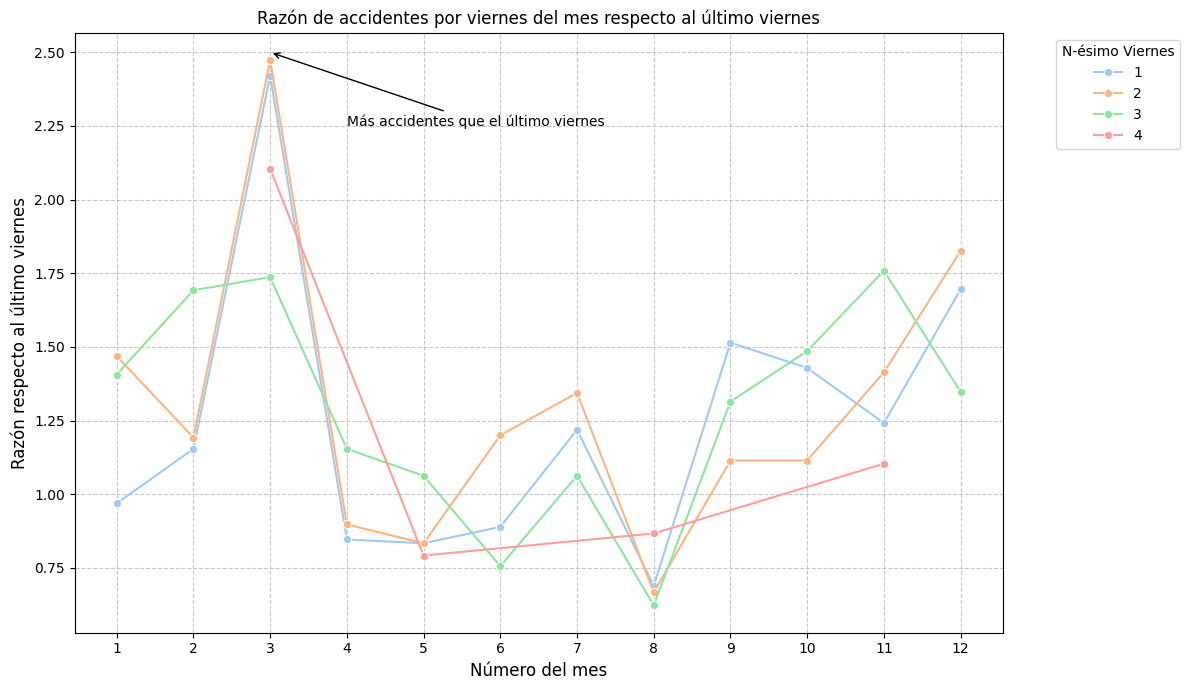

In [25]:
plt.figure(figsize=(12, 7))

df_ratios = df_ratios[df_ratios['ratio_last_friday'] != 1]

ax = sns.lineplot(data=df_ratios, x='MES', y='ratio_last_friday', hue='num_viernes', palette='pastel', marker='o')
ax.annotate("Más accidentes que el último viernes",
            xy = [3, 2.5],
            xytext = [4, 2.25],
            arrowprops=dict(arrowstyle="->"))

plt.title('Razón de accidentes por viernes del mes respecto al último viernes')
plt.xlabel('Número del mes', fontsize=12)
plt.ylabel('Razón respecto al último viernes', fontsize=12)
plt.xticks(ticks=range(1, 13))
plt.legend(title='N-ésimo Viernes', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

La gráfica muestra la razón de un viernes contra el último del mes, identificando la medición por el marcador 'o'. Aquellos lugares donde no se encuentre el marcador, se identifican como interpolación entre esos meses.

El ciclo escolar 2024-2025 tuvo inicio el 26 de agosto de 2024 ([Calendario escolar 2024-2025](https://www.gob.mx/cms/uploads/article/main_image/146086/Calendario_Escolar_BASICA-01.JPG)), correspondiente a la última semana del mes. A partir de septiembre en el último viernes del mes ocurren más accidentes.

Los primeros dos viernes del mes suelen tener más accidentes que el último durante el primer cuatrimestre. Este valor se reduce durante el segundo cuatrimestre, y en el último cuatrimestre el tercer viernes comienza a incrementar su valor respecto al último.

## Acidentes por Generación

In [ ]:
# Reemplazar el valor 99 por NaN, ya que 99 no identifica una edad
df_edades = df_hmo.replace({'ID_EDAD': {99: np.nan}})

# identificar generación
df_edades['GENERACION'] = np.floor(df_edades['ID_EDAD'] / 10) * 10
print(
    sorted(df_edades['ID_EDAD'].unique().tolist())
)

[0.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0, 37.0, 38.0, 39.0, 40.0, 41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 47.0, 48.0, 49.0, 50.0, 51.0, 52.0, 53.0, 54.0, 55.0, 56.0, 57.0, 58.0, 59.0, 60.0, 61.0, 62.0, 63.0, 64.0, 65.0, 66.0, 70.0, nan, 67.0, 68.0, 69.0, 71.0, 72.0, 73.0, 74.0, 75.0, 76.0, 77.0, 78.0, 79.0, 80.0, 81.0, 82.0, 83.0, 84.0, 85.0, 86.0, 87.0, 88.0, 89.0]


In [49]:
df_edades[df_edades['ID_EDAD'] < 50]['ID_EDAD'].value_counts().sort_index()

ID_EDAD
0.0     886
12.0      7
13.0      9
14.0      8
15.0     14
16.0     30
17.0     98
18.0    192
19.0    243
20.0    258
21.0    288
22.0    289
23.0    338
24.0    284
25.0    312
26.0    293
27.0    303
28.0    291
29.0    296
30.0    289
31.0    271
32.0    268
33.0    292
34.0    237
35.0    282
36.0    267
37.0    237
38.0    244
39.0    232
40.0    258
41.0    235
42.0    201
43.0    227
44.0    207
45.0    217
46.0    187
47.0    204
48.0    204
49.0    171
Name: count, dtype: int64

In [27]:
# Confirmación del reemplazo de 99 por np.nan
df_edades['ID_EDAD'].isna().sum()

np.int64(337)

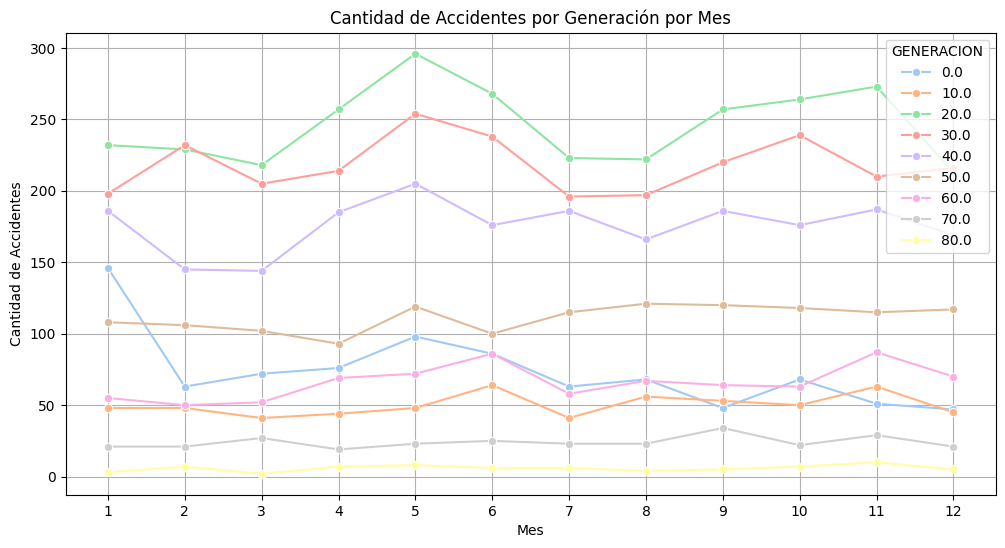

In [28]:
# Agrupar por mes y generación, después contar los sucesos
df_monthly_generation = df_edades.groupby(['MES', 'GENERACION']).size().reset_index(name='count')

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_monthly_generation, x='MES', y='count', hue='GENERACION', marker='o', palette='pastel')
plt.title('Cantidad de Accidentes por Generación por Mes')
plt.xlabel('Mes')
plt.ylabel('Cantidad de Accidentes')
plt.xticks(df_monthly_generation['MES'].unique())
plt.grid(True)
plt.show()

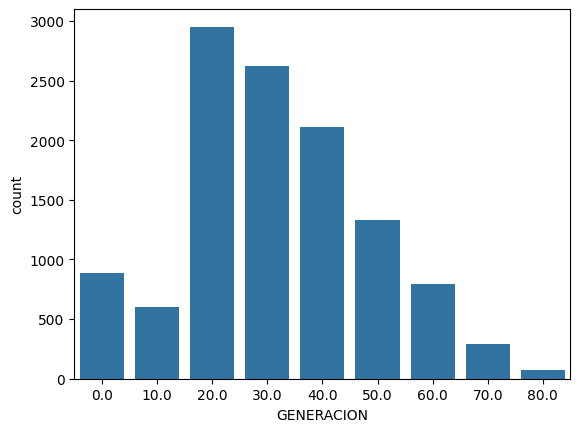

In [29]:
#fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 6))
sns.countplot(data=df_edades, x='GENERACION')
plt.show()

In [30]:
# Proporción de accidentes por tipo
df_edades['TIPACCID'].value_counts(normalize=True)

TIPACCID
Colisión con vehículo automotor          0.781920
Colisión con motocicleta                 0.088566
Colisión con objeto fijo                 0.066633
Colisión con peatón (atropellamiento)    0.024518
Colisión con ciclista                    0.013427
Caída de pasajero                        0.010008
Volcadura                                0.008923
Salida del camino                        0.005921
Colisión con ferrocarril                 0.000083
Name: proportion, dtype: float64

In [31]:
df_edades['CAUSAACCI'].value_counts(normalize=True)

CAUSAACCI
Conductor            0.990910
Peatón o pasajero    0.009007
Otra                 0.000083
Name: proportion, dtype: float64

## Accidentes Generación >70

In [32]:
acc_70 = df_edades.copy()
acc_70.shape

(11991, 42)

In [33]:
df_month_gen_se = acc_70.groupby(['MES', 'GENERACION', 'SEXO']).size().reset_index(name='count')

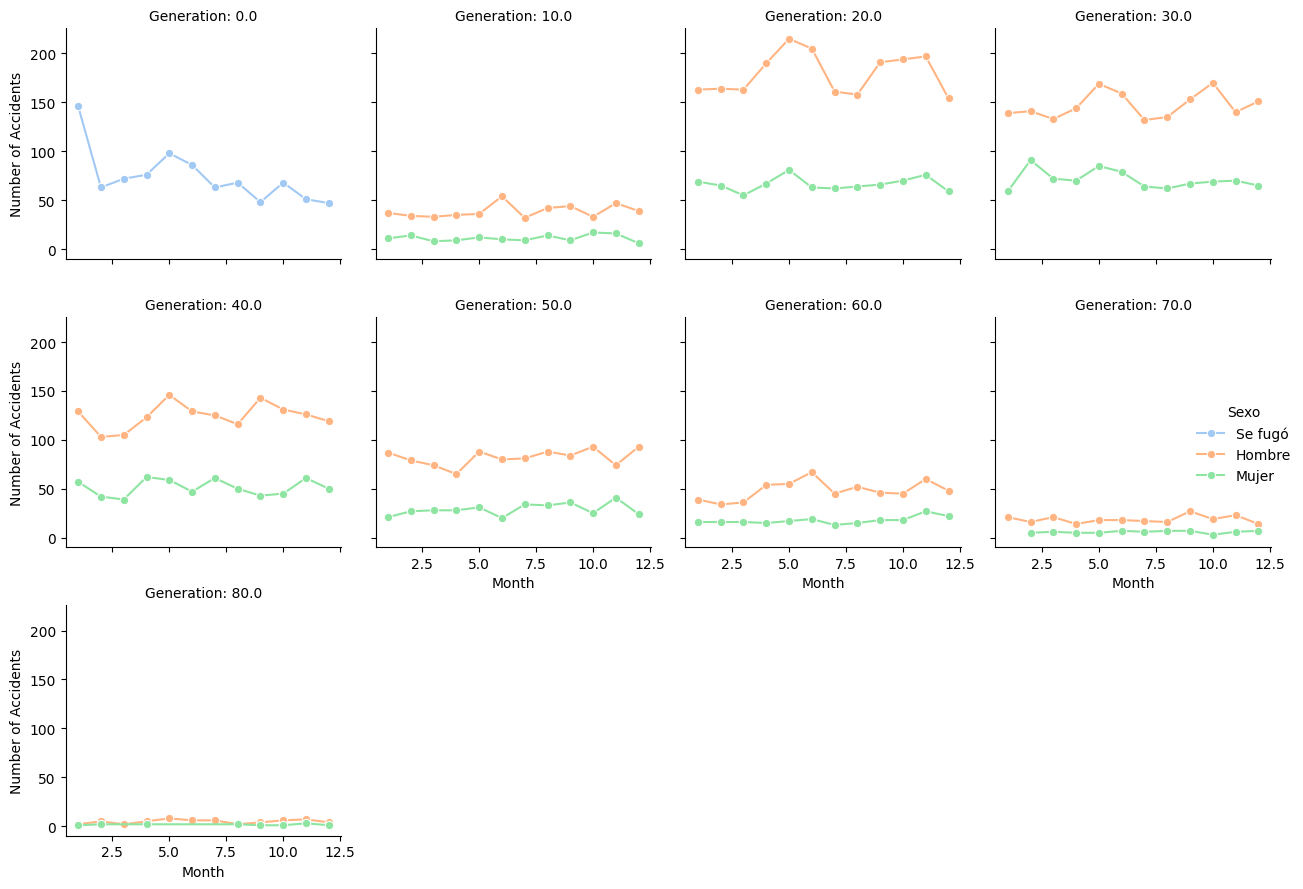

In [34]:
# Se usa el argumento errorbar en lugar de ci
g = sns.FacetGrid(df_month_gen_se, col='GENERACION', hue='SEXO', col_wrap=4, height=3, palette='pastel')
g.map(sns.lineplot, 'MES', 'count', marker='o', errorbar=None)
g.set_titles("Generation: {col_name:}")
g.set_axis_labels("Month", "Number of Accidents")
g.add_legend(title="Sexo")
plt.tight_layout()
plt.show()

## Censo Poblacional 2020

Para determinar de forma indirecta esta inferencia, se obtiene el censo poblacional de INEGI en 2020. Los datos de rangos de edad se encuentran en las variables:

- `P_12YMAS`: Población de 12 años y más
- `P_12YMAS_F`: Población femenina de 12 años y más
- `P_12YMAS_M`: Población masculina de 12 años y más
- `P_15YMAS`: Población de 15 años y más
- `P_15YMAS_F`: Población femenina de 15 años y más
- `P_15YMAS_M`: Población masculina de 15 años y más
- `P_18A24`: Población de 18 a 24 años
- `P_18A24_F`: Población femenina de 18 a 24 años
- `P_18A24_M`: Población masculina de 18 a 24 años
- `P_25A29`: Población de 25 a 29 años
- `P_25A29_F`: Población femenina de 25 a 29 años
- `P_25A29_M`: Población masculina de 25 a 29 años
- `P_30A34`: Población de 30 a 34 años
- `P_30A34_F`: Población femenina de 30 a 34 años
- `P_30A34_M`: Población masculina de 30 a 34 años
- `P_35A39`: Población de 35 a 39 años
- `P_35A39_F`: Población femenina de 35 a 39 años
- `P_35A39_M`: Población masculina de 35 a 39 años
- `P_40A44`: Población de 40 a 44 años
- `P_40A44_F`: Población femenina de 40 a 44 años
- `P_40A44_M`: Población masculina de 40 a 44 años
- `P_45A49`: Población de 45 a 49 años
- `P_45A49_F`: Población femenina de 45 a 49 años
- `P_45A49_M`: Población masculina de 45 a 49 años

In [35]:
censo_2020 = '../data/raw/conjunto_de_datos_iter_26CSV20.csv'
df_censo_2020 = pd.read_csv(censo_2020)
df_censo_2020_hmo = df_censo_2020[(df_censo_2020['NOM_MUN'] == 'Hermosillo') & (df_censo_2020['NOM_LOC'] != 'Total del Municipio')].copy()
df_censo_2020_hmo.head(3)

,ENTIDAD,NOM_ENT,MUN,NOM_MUN,LOC,NOM_LOC,LONGITUD,LATITUD,ALTITUD,POBTOT,...,VPH_CEL,VPH_INTER,VPH_STVP,VPH_SPMVPI,VPH_CVJ,VPH_SINRTV,VPH_SINLTC,VPH_SINCINT,VPH_SINTIC,TAMLOC
3352,26,Sonora,30,Hermosillo,1,Hermosillo,"110°57'30.469"" W","29°04'29.610"" N",200.0,855563,...,246615,189653,136543,90744,52642,6240,7586,57021,1509,13
3353,26,Sonora,30,Hermosillo,115,Real del Alamito [Fraccionamiento Campestre],"110°51'11.607"" W","29°13'15.730"" N",274.0,312,...,91,30,47,12,5,3,5,63,2,2
3354,26,Sonora,30,Hermosillo,116,Los Alamitos,"111°22'55.960"" W","28°50'12.636"" N",80.0,6,...,3,2,2,1,1,1,0,1,0,1


In [ ]:
columnas_edades = {
    'NOM_LOC': 'localidad',
    'P_18A24': '18 a 24',
    'P_25A29': '25 a 29',
    'P_30A34': '30 a 34',
    'P_35A39': '35 a 39',
    'P_40A44': '40 a 44',
    'P_45A49': '45 a 49'
    }

df_censo_2020_edades = df_censo_2020_hmo.copy()
df_censo_2020_edades = df_censo_2020_edades[columnas_edades.keys()].rename(columns=columnas_edades).reset_index(drop=True).set_index('localidad')

# Reemplazo de valores no numéricos
df_censo_2020_edades = df_censo_2020_edades.replace({'*': 0})
df_censo_2020_edades = df_censo_2020_edades.replace({'N/D': 0})

# Conversión de tipos a int64
df_censo_2020_edades[['18 a 24', '25 a 29', '30 a 34', '35 a 39', '40 a 44', '45 a 49']] = df_censo_2020_edades[['18 a 24', '25 a 29', '30 a 34', '35 a 39', '40 a 44', '45 a 49']].astype('int64')

df_censo_2020_edades['18 a 29'] = df_censo_2020_edades['18 a 24'] + df_censo_2020_edades['25 a 29']
df_censo_2020_edades['30 a 39'] = df_censo_2020_edades['30 a 34'] + df_censo_2020_edades['35 a 39']
df_censo_2020_edades['40 a 49'] = df_censo_2020_edades['40 a 44'] + df_censo_2020_edades['45 a 49']
df_censo_2020_edades['pob total'] = df_censo_2020_edades['18 a 29'] + df_censo_2020_edades['30 a 39'] + df_censo_2020_edades['40 a 49']
df_censo_2020_edades.drop(columns=['18 a 24', '25 a 29', '30 a 34', '35 a 39', '40 a 44', '45 a 49'], inplace=True)

In [37]:
pob_total = df_censo_2020_edades['pob total'].sum()
pob_1 = df_censo_2020_edades['18 a 29'].sum() / pob_total
pob_2 = df_censo_2020_edades['30 a 39'].sum() / pob_total
pob_3 = df_censo_2020_edades['40 a 49'].sum() / pob_total
print(f"Población total: {pob_total:,.0f}")
print(f"Población de 18 a 29's: {pob_1:.2%}")
print(f"Población de 30 a 39's: {pob_2:.2%}")
print(f"Población de 40 a 49's: {pob_3:.2%}")

Población total: 465,772
Población de 18 a 29's: 42.18%
Población de 30 a 39's: 30.46%
Población de 40 a 49's: 27.36%


In [ ]:
# Calculate the proportion of accidents per generation
acc_gen_counts = df_edades['GENERACION'].value_counts().sort_index().to_frame()
# ¿Qué sería lo más correcto para determinar la población de la generación de 10?

display(acc_gen_counts)

,count
GENERACION,
0.0,886
10.0,601
20.0,2952
30.0,2619
40.0,2111
50.0,1334
60.0,793
70.0,288
80.0,70
